### Graph datasets (DIF, IF and DOMINANT)

#### 1. NCI1 (PyG built-in dataset)

In [7]:
import os, time, numpy as np, torch
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from algorithms import DIF 
from sklearn.ensemble import IsolationForest

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
import torch.nn as nn
import torch.nn.functional as F

# Load the data from PyG
ds = TUDataset(root='./data/TU', name='MUTAG')
graphs = [ds[i] for i in range(len(ds))]
labels = np.array([int(g.y.item()) for g in graphs]) # Binary classification label

# A few classes are regarded as outliers
cls, cnt = np.unique(labels, return_counts=True)
anom_label = cls[np.argmin(cnt)]
y_bin_all = (labels == anom_label).astype(int)

# Split data
rng = np.random.default_rng(0)
idx = np.arange(len(graphs)); rng.shuffle(idx)
normal_idx = idx[y_bin_all[idx] == 0]
anom_idx   = idx[y_bin_all[idx] == 1]

n_train_norm = int(0.7 * len(normal_idx))   # 70% for training
train_idx = normal_idx[:n_train_norm]
test_idx  = np.concatenate([normal_idx[n_train_norm:], anom_idx])
rng.shuffle(test_idx)

graphs_train = [graphs[i] for i in train_idx]
graphs_test  = [graphs[i] for i in test_idx]
y_test = y_bin_all[test_idx]
print(f"[SPLIT] Train(normals)={len(graphs_train)}  Test={len(graphs_test)}  Pos%={y_test.mean():.2%}")

# Random GIN graph representation（network_name='gin', pooling='sum')
class RandomGIN(nn.Module):
    def __init__(self, in_dim, n_hidden=100, n_emb=50, n_layers=5, act='tanh', dropout=0.0):
        super().__init__()
        acts = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'tanh': nn.Tanh(), 'leaky_relu': nn.LeakyReLU(0.1)}
        self.act = acts.get(act, nn.Tanh())
        self.dropout = nn.Dropout(dropout)

        def mlp(in_ch, out_ch):
            return nn.Sequential(nn.Linear(in_ch, out_ch), self.act, nn.Linear(out_ch, out_ch))

        layers = []
        dim = in_dim
        for _ in range(n_layers):
            layers.append(GINConv(mlp(dim, n_hidden)))
            dim = n_hidden
        self.gins = nn.ModuleList(layers)
        self.proj = nn.Linear(n_hidden, n_emb)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv in self.gins:
            x = conv(x, edge_index)
            x = self.act(x)
            x = self.dropout(x)
        g = global_add_pool(x, batch)          # pooling='sum'
        z = self.proj(g)                     
        return z

def embed_graphs(model, graphs, batch_size=512, device='cpu'):
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    model.eval()
    all_emb = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z = model(batch)
            all_emb.append(z.cpu())
    return torch.cat(all_emb, dim=0).numpy().astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_dim = ds.num_features if ds.num_features and ds.num_features > 0 else 1
gin = RandomGIN(in_dim=in_dim, n_hidden=100, n_emb=50, n_layers=5, act='tanh', dropout=0.0).to(device)

X_train_g = embed_graphs(gin, graphs_train, device=device)  # Training graph embedding
X_test_g  = embed_graphs(gin, graphs_test,  device=device)  # Testing graph embedding

# Standardlization
scaler = StandardScaler().fit(X_train_g)
X_train = scaler.transform(X_train_g).astype(np.float32)
X_test  = scaler.transform(X_test_g).astype(np.float32)

[SPLIT] Train(normals)=87  Test=101  Pos%=62.38%


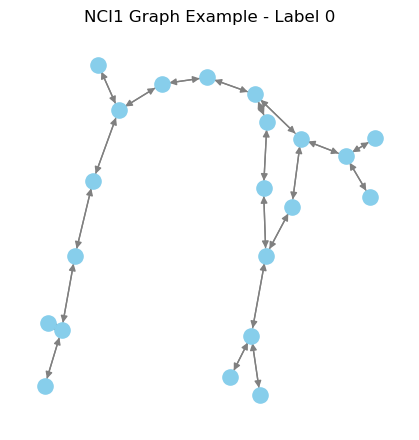

In [ ]:
# check a graph example
# from torch_geometric.utils import to_networkx
# import matplotlib.pyplot as plt

# g = ds[0]
# G = to_networkx(g)

# plt.figure(figsize=(4, 4))
# nx = __import__('networkx') 
# nx.draw(G, node_size=120, node_color='skyblue', edge_color='gray', with_labels=False)
# plt.title(f'NCI1 Graph Example - Label {g.y.item()}')
# plt.show()

In [9]:
# DIF
n_ensemble = 50              
n_estimators = 6
dif = DIF(n_ensemble=n_ensemble, n_estimators=n_estimators,
           random_state=0)

# Fitting
dif.fit(X_train)  
s_raw = dif.decision_function(X_test)
auc_raw = roc_auc_score(y_test, s_raw)
auc_neg = roc_auc_score(y_test, -s_raw)

score_dif = s_raw if auc_raw >= auc_neg else -s_raw
auc_dif = roc_auc_score(y_test, score_dif)
pr_dif  = average_precision_score(y_test, score_dif)

print(f"[DIF] AUC-ROC={auc_dif:.4f}  AUC-PR={pr_dif:.4f}  (Trees={n_ensemble*n_estimators})")

network additional parameters: {'n_hidden': [500, 100], 'n_emb': 20, 'skip_connection': None, 'dropout': None, 'activation': 'tanh', 'be_size': 50}


d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble\_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (87). max_samples will be set to n_samples for estimation.
  warn(
d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble\_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (87). max_samples will be set to n_samples for estimation.
  warn(
d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble\_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (87). max_samples will be set to n_samples for estimation.
  warn(
d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble\_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (87). max_samples will be set to n_samples for estimation.
  warn(
d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble

[DIF] AUC-ROC=0.7719  AUC-PR=0.8855  (Trees=300)


In [10]:
# IF
ifor = IsolationForest(
    n_estimators=n_ensemble*n_estimators,   
    max_samples=300, contamination='auto',
    random_state=0, n_jobs=-1
)

# Fitting
ifor.fit(X_train)

score_if = -ifor.score_samples(X_test)      
auc_if = roc_auc_score(y_test, score_if)
pr_if  = average_precision_score(y_test, score_if)

print(f"[IForest] AUC-ROC={auc_if:.4f}  AUC-PR={pr_if:.4f}  (Trees={n_ensemble*n_estimators})")

d:\Software\anaconda\envs\datascience\Lib\site-packages\sklearn\ensemble\_iforest.py:336: UserWarning: max_samples (300) is greater than the total number of samples (87). max_samples will be set to n_samples for estimation.
  warn(


[IForest] AUC-ROC=0.7878  AUC-PR=0.7774  (Trees=300)


In [8]:
import scipy.sparse as sp
from pygod.detector import DOMINANT
from torch_geometric.utils import to_scipy_sparse_matrix, from_scipy_sparse_matrix
from torch_geometric.data import Data

# Pack: small graphs -> one big graph  (block-diagonal adjacency)
def pack_graphs_to_big_graph(graph_list):
    assert len(graph_list) > 0
    feats, edges = [], []
    nodes_per_graph, gid_of_node = [], []
    offset = 0

    F = 1 if (graph_list[0].x is None or graph_list[0].x.numel() == 0) else graph_list[0].x.size(1)

    for gid, g in enumerate(graph_list):
        x = g.x.float() if (g.x is not None and g.x.numel() > 0) else torch.ones((g.num_nodes, F), dtype=torch.float32)
        feats.append(x)

        A = to_scipy_sparse_matrix(g.edge_index, num_nodes=g.num_nodes).tocsr()
        ii, jj = A.nonzero()
        edges.append((ii + offset, jj + offset))

        nodes_per_graph.append(np.arange(offset, offset + g.num_nodes))
        gid_of_node.extend([gid] * g.num_nodes)
        offset += g.num_nodes

    X_big = torch.cat(feats, dim=0).numpy().astype(np.float32)
    if len(edges):
        I = np.concatenate([e[0] for e in edges]); J = np.concatenate([e[1] for e in edges])
        V = np.ones_like(I, dtype=np.float32)
        A_big = sp.coo_matrix((V, (I, J)), shape=(offset, offset)).tocsr()
    else:
        A_big = sp.csr_matrix((offset, offset), dtype=np.float32)

    return X_big, A_big, nodes_per_graph

X_tr_big, A_tr_big, nodes_per_graph_tr = pack_graphs_to_big_graph(graphs_train)
X_te_big, A_te_big, nodes_per_graph_te = pack_graphs_to_big_graph(graphs_test)

print(f"[PACK] Train BigGraph: N={X_tr_big.shape[0]}, F={X_tr_big.shape[1]}, edges={A_tr_big.nnz}")
print(f"[PACK] Test  BigGraph: N={X_te_big.shape[0]}, F={X_te_big.shape[1]}, edges={A_te_big.nnz}")


# Standardization (fit on train big graph only)
scaler = StandardScaler().fit(X_tr_big)
X_tr_std = scaler.transform(X_tr_big).astype(np.float32)
X_te_std = scaler.transform(X_te_big).astype(np.float32)


# Convert to PyG Data
def to_pyg_data(X_std, A_sp):
    A_sp = A_sp.maximum(A_sp.T)  # ensure undirected
    x = torch.tensor(X_std, dtype=torch.float32)
    edge_index, _ = from_scipy_sparse_matrix(A_sp)
    return Data(x=x, edge_index=edge_index)

data_tr = to_pyg_data(X_tr_std, A_tr_big)
data_te = to_pyg_data(X_te_std, A_te_big)


# Train DOMINANT on train big graph
dom = DOMINANT(hid_dim=64, num_layers=2, epoch=80, lr=1e-3, weight_decay=5e-5, dropout=0.1)
dom.fit(data_tr)


# Score nodes on test big graph -> aggregate per-graph -> graph-level metrics
node_scores = dom.decision_function(data_te)
if isinstance(node_scores, torch.Tensor):
    node_scores = node_scores.detach().cpu().numpy().astype(np.float32)

graph_scores = np.zeros(len(nodes_per_graph_te), dtype=np.float32)
offset = 0
for gid, node_idx in enumerate(nodes_per_graph_te):
    L = len(node_idx)
    s = node_scores[offset:offset+L]
    graph_scores[gid] = float(np.max(s))   
    offset += L

auc_dominant = roc_auc_score(y_test, graph_scores)
pr_dominant  = average_precision_score(y_test, graph_scores)
print(f"[DOMINANT] AUC-ROC={auc_dominant:.4f}  AUC-PR={pr_dominant:.4f}  (n_test_graphs={len(graphs_test)})")

[PACK] Train BigGraph: N=1699, F=7, edges=3824
[PACK] Test  BigGraph: N=1672, F=7, edges=3618
[DOMINANT] AUC-ROC=0.8367  AUC-PR=0.8599  (n_test_graphs=101)


In [12]:
print("\n========= SUMMARY (TUdataset) =========")
print(f"DIF     : AUC-ROC={auc_dif:.4f}  AUC-PR={pr_dif:.4f}")
print(f"IForest : AUC-ROC={auc_if:.4f}  AUC-PR={pr_if:.4f}")
print(f"DOMINANT   : AUC-ROC={auc_dominant:.4f}  AUC-PR={pr_dominant:.4f}")


========= SUMMARY (TUdataset) =========
DIF     : AUC-ROC=0.7719  AUC-PR=0.8855
IForest : AUC-ROC=0.7878  AUC-PR=0.7774
DOMINANT   : AUC-ROC=0.8367  AUC-PR=0.8599


#### 2. Created datasets

In [2]:
import numpy as np
import torch
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest
from algorithms import DIF

from torch_geometric.data import Data
from torch_geometric.utils import erdos_renyi_graph, to_scipy_sparse_matrix, from_scipy_sparse_matrix
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
import torch.nn as nn

from pygod.detector import DOMINANT 

rng = np.random.default_rng(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Synthetic graph dataset
def make_cluster_graph(n_nodes=30, p_in=0.15, p_out=0.02, n_feats=16, n_comm=3):
    # Generate multi-community small graphs + community mean features (linearly separable but noisy)
    # Community division
    comm_size = n_nodes // n_comm
    labels = np.repeat(np.arange(n_comm), comm_size)
    if labels.size < n_nodes:
        labels = np.concatenate([labels, np.full(n_nodes - labels.size, n_comm - 1)])
    labels = rng.permutation(labels)

    # Structure: Block random graph
    A = sp.csr_matrix((n_nodes, n_nodes), dtype=np.float32)
    for c in range(n_comm):
        idx = np.where(labels == c)[0]
        Ei, Ej = erdos_renyi_graph(num_nodes=len(idx), edge_prob=p_in)
        Ei = idx[Ei.numpy()]; Ej = idx[Ej.numpy()]
        A += sp.coo_matrix((np.ones_like(Ei, dtype=np.float32), (Ei, Ej)), shape=(n_nodes, n_nodes))
    
    # Sparse cross community
    cross = int(p_out * n_nodes * n_nodes)
    ii = rng.integers(0, n_nodes, size=cross); jj = rng.integers(0, n_nodes, size=cross)
    A += sp.coo_matrix((np.ones_like(ii, dtype=np.float32), (ii, jj)), shape=(n_nodes, n_nodes))
    A = (A + A.T)
    A = A.tocsr()
    A[A > 0] = 1
    A.setdiag(0); A.eliminate_zeros()

    # Node characteristics: One mean vector and noise for each community
    centers = rng.normal(0, 1.0, size=(n_comm, n_feats)).astype(np.float32)
    X = centers[labels] + rng.normal(0, 0.3, size=(n_nodes, n_feats)).astype(np.float32)

    edge_index, _ = from_scipy_sparse_matrix(A)
    x = torch.tensor(X, dtype=torch.float32)
    return Data(x=x, edge_index=edge_index), labels

def inject_attribute_anomaly(g: Data, sigma=2.0, ratio=0.2): 
    # Attribute anomaly: increase noise for some nodes
    g = Data(x=g.x.clone(), edge_index=g.edge_index.clone())
    n = g.num_nodes
    k = max(1, int(n * ratio))
    idx = rng.choice(n, size=k, replace=False)
    g.x[idx] += torch.tensor(rng.normal(0, sigma, size=(k, g.x.size(1))), dtype=torch.float32)
    return g

def inject_structure_anomaly(g: Data, k_noise_edges=20):
    # Structural anomaly: random edge addition/modification
    g = Data(x=g.x.clone(), edge_index=g.edge_index.clone())
    A = to_scipy_sparse_matrix(g.edge_index, num_nodes=g.num_nodes).tolil()
    n = g.num_nodes
    for _ in range(k_noise_edges):
        u, v = int(rng.integers(0, n)), int(rng.integers(0, n))
        if u == v: continue
        A[u, v] = 1; A[v, u] = 1
    A = A.tocsr()
    edge_index, _ = from_scipy_sparse_matrix(A)
    g.edge_index = edge_index
    return g

def build_dataset(n_train_norm=500, n_test_norm=100, n_test_anom=60,
                  n_nodes=30, n_feats=16):
    graphs_train = []
    for _ in range(n_train_norm):
        g, _ = make_cluster_graph(n_nodes=n_nodes, n_feats=n_feats)
        graphs_train.append(g)

    graphs_test = []
    # Normality
    for _ in range(n_test_norm):
        g, _ = make_cluster_graph(n_nodes=n_nodes, n_feats=n_feats)
        graphs_test.append(g)
    # Exception (half attribute and half structure)
    for i in range(n_test_anom):
        g, _ = make_cluster_graph(n_nodes=n_nodes, n_feats=n_feats)
        if i % 2 == 0:
            g = inject_attribute_anomaly(g, sigma=2.5, ratio=0.3)
        else:
            g = inject_structure_anomaly(g, k_noise_edges=25)
        graphs_test.append(g)

    y_test_graph = np.array([0]*n_test_norm + [1]*n_test_anom, dtype=np.int32)
    # Disrupt the test
    perm = rng.permutation(len(graphs_test))
    graphs_test = [graphs_test[i] for i in perm]
    y_test_graph = y_test_graph[perm]
    return graphs_train, graphs_test, y_test_graph

graphs_train, graphs_test, y_test_graph = build_dataset()
print(f"[DATA] Train_norm={len(graphs_train)}  Test={len(graphs_test)}  Test Pos%={y_test_graph.mean():.2%}")

# Random GIN graph representation → Graph vector（DIF/IF)
class RandomGIN(nn.Module):
    def __init__(self, in_dim, n_hidden=100, n_emb=50, n_layers=5, act='tanh', dropout=0.0):
        super().__init__()
        acts = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'tanh': nn.Tanh(), 'leaky_relu': nn.LeakyReLU(0.1)}
        self.act = acts.get(act, nn.Tanh())
        self.dropout = nn.Dropout(dropout)
        def mlp(in_ch, out_ch):
            return nn.Sequential(nn.Linear(in_ch, out_ch), self.act, nn.Linear(out_ch, out_ch))
        layers, dim = [], in_dim
        for _ in range(n_layers):
            layers.append(GINConv(mlp(dim, n_hidden)))
            dim = n_hidden
        self.gins = nn.ModuleList(layers)
        self.proj = nn.Linear(n_hidden, n_emb)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv in self.gins:
            x = conv(x, edge_index); x = self.act(x); x = self.dropout(x)
        g = global_add_pool(x, batch)
        z = self.proj(g)
        return z

def embed_graphs(model, graphs, batch_size=256, device='cpu'):
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    model.eval(); out = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out.append(model(batch).cpu())
    return torch.cat(out, dim=0).numpy().astype(np.float32)

in_dim = graphs_train[0].x.size(1)
gin = RandomGIN(in_dim=in_dim, n_hidden=100, n_emb=50, n_layers=5, act='tanh', dropout=0.0).to(device)

X_train_g = embed_graphs(gin, graphs_train, device=device)
X_test_g  = embed_graphs(gin, graphs_test,  device=device)

# Standardlization
scaler = StandardScaler().fit(X_train_g)
X_train = scaler.transform(X_train_g).astype(np.float32)
X_test  = scaler.transform(X_test_g).astype(np.float32)
y_test  = y_test_graph

[DATA] Train_norm=500  Test=160  Test Pos%=37.50%


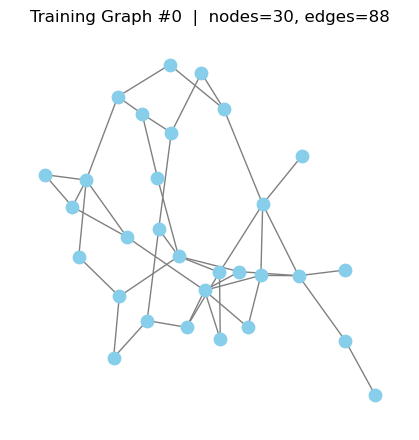

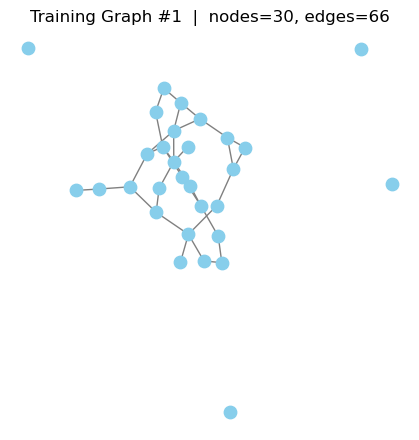

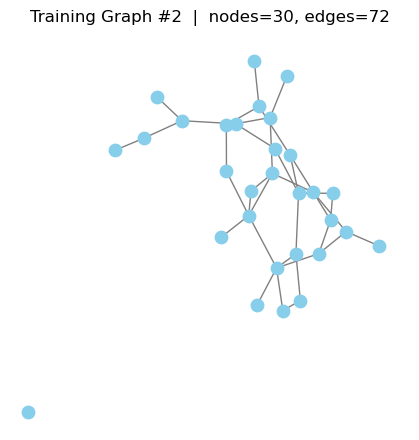

In [ ]:
# import matplotlib.pyplot as plt
# import networkx as nx
# from torch_geometric.utils import to_networkx

# for i in range(3):
#     g = graphs_train[i]
#     G = to_networkx(g, to_undirected=True)
    
#     plt.figure(figsize=(4,4))
#     nx.draw(
#         G, 
#         node_size=80,
#         node_color='skyblue',
#         edge_color='gray',
#         with_labels=False
#     )
#     plt.title(f"Training Graph #{i}  |  nodes={g.num_nodes}, edges={g.num_edges}")
#     plt.axis('off')
#     plt.show()


In [6]:
# DIF
from algorithms import DIF 
from sklearn.metrics import roc_auc_score, average_precision_score

n_ensemble, n_estimators = 50, 6
dif = DIF(n_ensemble=n_ensemble, n_estimators=n_estimators,
           random_state=42)
dif.fit(X_train)
s_raw = dif.decision_function(X_test)

auc_raw = roc_auc_score(y_test, s_raw); auc_neg = roc_auc_score(y_test, -s_raw)
score_dif = s_raw if auc_raw >= auc_neg else -s_raw
auc_dif = roc_auc_score(y_test, score_dif)
pr_dif  = average_precision_score(y_test, score_dif)
print(f"[DIF]      AUC-ROC={auc_dif:.4f}  AUC-PR={pr_dif:.4f}  (trees={n_ensemble*n_estimators})")

network additional parameters: {'n_hidden': [500, 100], 'n_emb': 20, 'skip_connection': None, 'dropout': None, 'activation': 'tanh', 'be_size': 50}
[DIF]      AUC-ROC=0.5535  AUC-PR=0.4717  (trees=300)


In [5]:
# IF
ifor = IsolationForest(
    n_estimators=n_ensemble*n_estimators,
    max_samples=256, contamination='auto',
    random_state=42, n_jobs=-1
)
ifor.fit(X_train)
score_if = -ifor.score_samples(X_test)
auc_if = roc_auc_score(y_test, score_if)
pr_if  = average_precision_score(y_test, score_if)
print(f"[IForest]  AUC-ROC={auc_if:.4f}  AUC-PR={pr_if:.4f}  (trees={n_ensemble*n_estimators})")

[IForest]  AUC-ROC=0.6958  AUC-PR=0.7197  (trees=300)


In [18]:
def pack_graphs_to_big_graph(graph_list):
   # Pack multiple small graphs into one big graph (block-diagonal adjacency).This lets DOMINANT (single-graph detector) train once over many graphs.
    feats, edges, nodes_per_graph = [], [], []
    offset, F = 0, graph_list[0].x.size(1)
    for g in graph_list:
        feats.append(g.x.float())
        A = to_scipy_sparse_matrix(g.edge_index, num_nodes=g.num_nodes).tocsr()
        ii, jj = A.nonzero()
        edges.append((ii + offset, jj + offset))
        nodes_per_graph.append(np.arange(offset, offset + g.num_nodes))
        offset += g.num_nodes

    X_big = torch.cat(feats, dim=0).numpy().astype(np.float32)
    if edges:
        I = np.concatenate([e[0] for e in edges]); J = np.concatenate([e[1] for e in edges])
        V = np.ones_like(I, dtype=np.float32)
        A_big = sp.coo_matrix((V, (I, J)), shape=(offset, offset)).tocsr()
    else:
        A_big = sp.csr_matrix((offset, offset), dtype=np.float32)
    return X_big, A_big, nodes_per_graph

# Pack train/test
X_tr_big, A_tr_big, nodes_tr = pack_graphs_to_big_graph(graphs_train)
X_te_big, A_te_big, nodes_te = pack_graphs_to_big_graph(graphs_test)

# Standardize by train stats only
scaler2 = StandardScaler().fit(X_tr_big)
X_tr_std = scaler2.transform(X_tr_big).astype(np.float32)
X_te_std = scaler2.transform(X_te_big).astype(np.float32)

def to_pyg_data(X_std, A_sp):
    """Convert (X, A) to PyG Data; force undirected adjacency."""
    A_sp = A_sp.maximum(A_sp.T)
    x = torch.tensor(X_std, dtype=torch.float32)
    edge_index, _ = from_scipy_sparse_matrix(A_sp)
    return Data(x=x, edge_index=edge_index)

data_tr = to_pyg_data(X_tr_std, A_tr_big)
data_te = to_pyg_data(X_te_std, A_te_big)

# Train DOMINANT on the big train graph
dom = DOMINANT(hid_dim=64, num_layers=2, epoch=80, lr=1e-3, weight_decay=5e-5, dropout=0.1)
dom.fit(data_tr)

# Get node-level scores on the test big graph
node_scores = dom.decision_function(data_te)
if isinstance(node_scores, torch.Tensor):
    node_scores = node_scores.detach().cpu().numpy().astype(np.float32)

# Aggregate to graph-level scores (use MAX for higher sensitivity; change to MEAN if desired)
graph_scores = np.zeros(len(nodes_te), dtype=np.float32)
offset = 0
for gid, node_idx in enumerate(nodes_te):
    L = len(node_idx)
    s = node_scores[offset:offset+L]
    graph_scores[gid] = float(np.max(s))   # or: float(np.mean(s))
    offset += L

auc_dom = roc_auc_score(y_test, graph_scores)
pr_dom  = average_precision_score(y_test, graph_scores)
print(f"[DOMINANT] AUC-ROC={auc_dom:.4f}  AUC-PR={pr_dom:.4f}  (n_test_graphs={len(graphs_test)})")

[DOMINANT] AUC-ROC=0.6573  AUC-PR=0.7453  (n_test_graphs=140)


In [19]:
# Summary 
print("\n======== SUMMARY (Graph-level) =========")
print(f"DIF      : AUC-ROC={auc_dif:.4f}  AUC-PR={pr_dif:.4f}")
print(f"IForest  : AUC-ROC={auc_if:.4f}  AUC-PR={pr_if:.4f}")
print(f"DOMINANT : AUC-ROC={auc_dom:.4f}  AUC-PR={pr_dom:.4f}")


======== SUMMARY (Graph-level) =========
DIF      : AUC-ROC=0.5760  AUC-PR=0.5519
IForest  : AUC-ROC=0.5953  AUC-PR=0.5588
DOMINANT : AUC-ROC=0.6573  AUC-PR=0.7453
